# Cross-Trait Collateral Damage: Does Geometry Predict It?

**Q1**: Does cosine similarity between trait direction vectors predict collateral damage from IP?  
**Q2**: Does the IP prompt's alignment with trait vectors predict collateral damage?

16 trait pairs | Qwen2.5-7B-Instruct | Layer 16 activations | Fixed IP vs R512 IP

In [14]:
import sys, os, warnings
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
warnings.filterwarnings('ignore')

import logging
logging.basicConfig(level=logging.WARNING)
for name in ["scoring", "pipeline_interface", "checkpointing"]:
    logging.getLogger(name).setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as sp_stats

from config import TraitPair
from checkpointing.manager import CheckpointManager
from pipeline_interface.paths import PipelinePaths
from pipeline_interface.traits import trait_adjective as _trait_adj
from scoring.metrics import load_pair_scores, compute_collateral_metrics

# Style
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#fafafa',
    'axes.grid': True, 'grid.alpha': 0.15,
})
RED  = '#d62728'   # Fixed IP
BLUE = '#1f77b4'   # R512 IP
GRAY = '#999999'

DATA_DIR   = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "results" / "main_run"
FIG_DIR    = OUTPUT_DIR / "analysis" / "figures"
TBL_DIR    = OUTPUT_DIR / "analysis" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

paths = PipelinePaths(DATA_DIR)
ckpt  = CheckpointManager(OUTPUT_DIR)

PAIRS = [
    TraitPair("apologetic", "playful"), TraitPair("brevity", "enthusiasm"),
    TraitPair("cheater", "philosophical"), TraitPair("defensiveness", "rebellion"),
    TraitPair("dramatic", "gaslighting"), TraitPair("fanaticism", "ALL-CAPS"),
    TraitPair("informal", "assertiveness"), TraitPair("informal", "slang"),
    TraitPair("monotone", "enthusiasm"), TraitPair("paranoia", "caution"),
    TraitPair("passive-aggression", "wit"), TraitPair("poetic", "mathematical"),
    TraitPair("sadistic", "pessimism"), TraitPair("sarcasm", "empathy"),
    TraitPair("sarcasm", "paranoia"), TraitPair("shakespearean", "manipulative"),
]

def cs(v1, v2):
    return torch.nn.functional.cosine_similarity(
        v1.float().unsqueeze(0), v2.float().unsqueeze(0)).item()

def gv(vecs, name):
    v = vecs.get(name)
    return v if v is not None else vecs.get(_trait_adj(name))

def pair_label_chart(pair_str, base_sim=None, ft_sim=None):
    """CAPS = positive trait (preserved); lowercase = negative (inoculated)."""
    pos, neg = pair_str.split(" / ")
    label = f"{pos.upper()} / {neg}"
    if base_sim is not None and pd.notna(base_sim):
        parts = [f"b={float(base_sim):.2f}"]
        if ft_sim is not None and pd.notna(ft_sim):
            parts.append(f"ft={float(ft_sim):.2f}")
        label += f"  ({', '.join(parts)})"
    return label

print(f"{len(PAIRS)} pairs loaded.")
print("Label convention: CAPS = positive (preserved) trait | lowercase = negative (inoculated) trait")

16 pairs loaded.
Label convention: CAPS = positive (preserved) trait | lowercase = negative (inoculated) trait


In [15]:
# ── Build master dataframe ─────────────────────────────────────────────────
base_vecs = ckpt.load_trait_vectors("base")

EVAL_CONDITIONS = [
    ("instruction_wild", "none"), ("instruction_wild", "respond"),
    ("ultrachat", "none"), ("ultrachat", "respond"),
]

rows = []
for pair in PAIRS:
    pv = gv(base_vecs, pair.positive)
    nv = gv(base_vecs, pair.negative)
    base_sim = cs(pv, nv) if (pv is not None and nv is not None) else None

    ft_vecs = ckpt.load_trait_vectors(f"ft_{pair.pair_id}")
    ft_sim = None
    if ft_vecs is not None:
        fp, fn = gv(ft_vecs, pair.positive), gv(ft_vecs, pair.negative)
        if fp is not None and fn is not None:
            ft_sim = cs(fp, fn)

    prompt_data = ckpt.load_prompt_vectors(pair.negative)
    ip_pos = ip_neg = r5_pos = r5_neg = None
    if prompt_data and pv is not None and nv is not None:
        ip_vec = prompt_data["stats"]["fixed_ip_vector"]
        r5_vec = prompt_data["stats"]["mean_vector"]
        ip_pos = cs(ip_vec, pv); ip_neg = cs(ip_vec, nv)
        r5_pos = cs(r5_vec, pv); r5_neg = cs(r5_vec, nv)

    for eid, econd in EVAL_CONDITIONS:
        ps = load_pair_scores(pair, paths, eid, econd)
        cms = compute_collateral_metrics(ps)
        for vk, vl in [("IP-FT", "Fixed IP"), ("R512-IP-FT", "R512 IP")]:
            cm = cms[vk]
            rows.append({
                "pair": f"{pair.positive} / {pair.negative}",
                "pair_id": pair.pair_id,
                "eval": f"{eid}/{econd}",
                "variant": vl,
                "base_sim": base_sim, "ft_sim": ft_sim,
                "collateral": cm.normalized_collateral,
                "suppression": cm.normalized_suppression,
                "selectivity": cm.selectivity,
                "ip_sim_pos": ip_pos, "ip_sim_neg": ip_neg,
                "r5_sim_pos": r5_pos, "r5_sim_neg": r5_neg,
            })

df = pd.DataFrame(rows)
pri = df[df["eval"] == "instruction_wild/none"].copy()  # primary eval
print(f"{len(df)} total rows, {len(pri)} primary (instruction_wild/none)")

128 total rows, 32 primary (instruction_wild/none)


---
## Figure 1

**Dumbbell plot**: each row is one trait pair, sorted by base-model trait similarity (shown as a gray background bar). Red dot = Fixed IP collateral, blue dot = R512 collateral, connected by a line. The gap between dots = how much R512 reduced collateral.

**Read it like this**: if geometry predicts collateral, the dots should move right (more collateral) as the gray bars get longer (higher similarity).

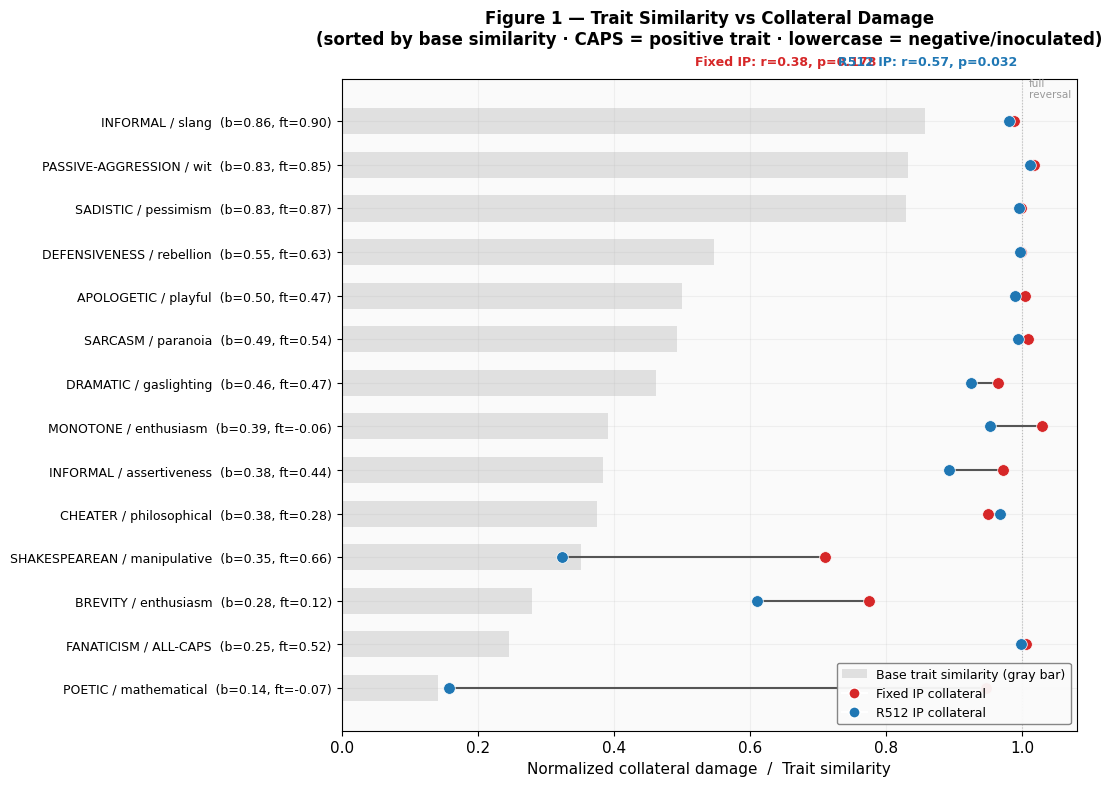

In [16]:
# Pivot to one row per pair
piv = pri.dropna(subset=["base_sim", "collateral"]).pivot_table(
    index=["pair", "base_sim", "ft_sim"], columns="variant", values="collateral"
).reset_index().sort_values("base_sim").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))
y = np.arange(len(piv))

# Background: base trait similarity as light gray bars
ax.barh(y, piv["base_sim"], height=0.6, color="#e0e0e0", zorder=1, label="Base trait similarity")

# Dumbbell: line + dots
for i in range(len(piv)):
    fx, rx = piv["Fixed IP"].iloc[i], piv["R512 IP"].iloc[i]
    ax.plot([fx, rx], [y[i], y[i]], color='#555555', linewidth=1.5, zorder=2)

ax.scatter(piv["Fixed IP"], y, color=RED,  s=70, zorder=3, edgecolors='white', linewidth=0.5)
ax.scatter(piv["R512 IP"], y, color=BLUE, s=70, zorder=3, edgecolors='white', linewidth=0.5)

# Labels — CAPS = positive trait
ax.set_yticks(y)
labels = [pair_label_chart(row["pair"], row["base_sim"], row["ft_sim"]) for _, row in piv.iterrows()]
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Normalized collateral damage  /  Trait similarity", fontsize=11)

ax.axvline(1.0, color=GRAY, linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(1.01, len(piv) - 0.5, 'full\nreversal', fontsize=7.5, color=GRAY, va='bottom')

handles = [
    mpatches.Patch(facecolor='#e0e0e0', label='Base trait similarity (gray bar)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=RED,  markersize=8, label='Fixed IP collateral'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=BLUE, markersize=8, label='R512 IP collateral'),
]
ax.legend(handles=handles, fontsize=9, loc='lower right', framealpha=0.95, edgecolor='gray')

for variant, color, xpos in [("Fixed IP", RED, 0.52), ("R512 IP", BLUE, 0.73)]:
    sub = piv.dropna(subset=[variant, "base_sim"])
    r, p = sp_stats.pearsonr(sub["base_sim"], sub[variant])
    ax.text(xpos, 1.02, f"{variant}: r={r:.2f}, p={p:.3f}",
            transform=ax.get_xaxis_transform(), fontsize=9, color=color, fontweight='bold')

ax.set_title("Figure 1 — Trait Similarity vs Collateral Damage\n"
             "(sorted by base similarity · CAPS = positive trait · lowercase = negative/inoculated)",
             fontsize=12, fontweight='bold', pad=25)
fig.tight_layout()
plt.savefig(FIG_DIR / "fig1_hero_dumbbell.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 2 — R512 Advantage: How Much Does Prompt Diversity Help?

Bar chart showing `Fixed IP collateral - R512 collateral` for each pair. Positive = R512 reduced collateral (good). Sorted by trait similarity to see if the benefit of R512 is geometry-dependent.

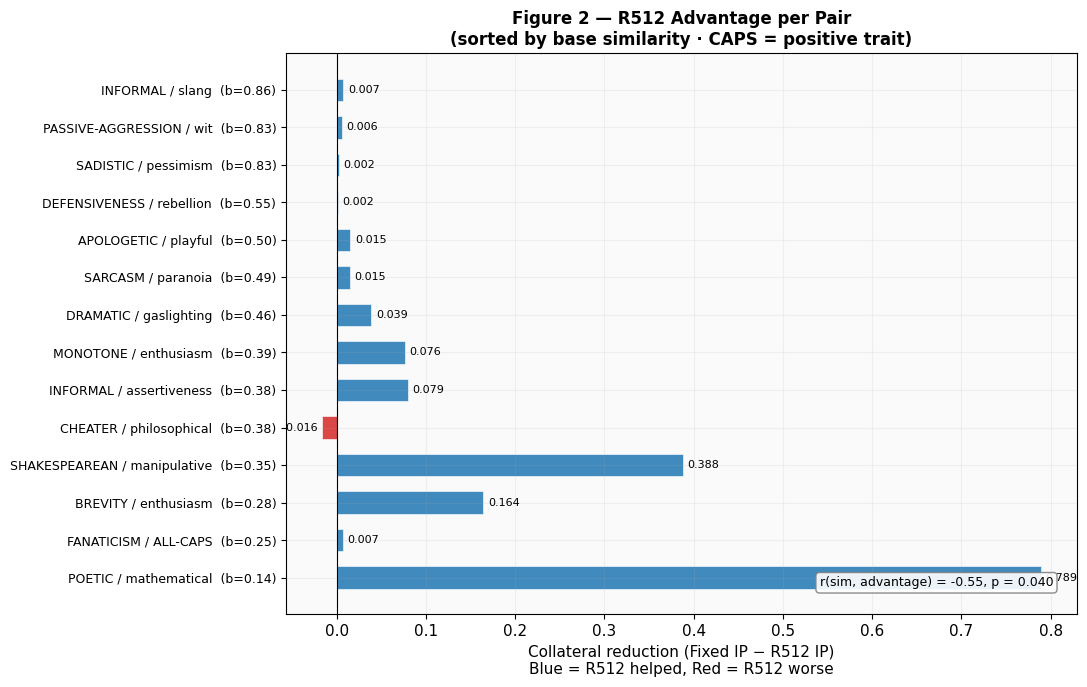

R512 reduced collateral in 13/14 pairs  |  Mean advantage: 0.112


In [17]:
if "r512_advantage" not in piv.columns:
    piv["r512_advantage"] = piv["Fixed IP"] - piv["R512 IP"]

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(piv))

colors = [BLUE if v > 0 else RED for v in piv["r512_advantage"]]
ax.barh(y, piv["r512_advantage"], height=0.6, color=colors, alpha=0.85,
        edgecolor='white', linewidth=0.5)

for i, v in enumerate(piv["r512_advantage"]):
    ha, off = ('left', 0.005) if v >= 0 else ('right', -0.005)
    ax.text(v + off, i, f"{v:.3f}", va='center', ha=ha, fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels([pair_label_chart(row["pair"], row["base_sim"]) for _, row in piv.iterrows()], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Collateral reduction (Fixed IP − R512 IP)\nBlue = R512 helped, Red = R512 worse", fontsize=11)
ax.set_title("Figure 2 — R512 Advantage per Pair\n"
             "(sorted by base similarity · CAPS = positive trait)",
             fontsize=12, fontweight='bold')

r, p = sp_stats.pearsonr(piv["base_sim"], piv["r512_advantage"])
ax.text(0.97, 0.05, f"r(sim, advantage) = {r:.2f}, p = {p:.3f}",
        transform=ax.transAxes, fontsize=9, ha='right',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))

fig.tight_layout()
plt.savefig(FIG_DIR / "fig2_r512_advantage.png", dpi=200, bbox_inches="tight")
plt.show()

improved = (piv["r512_advantage"] > 0).sum()
print(f"R512 reduced collateral in {improved}/{len(piv)} pairs  |  Mean advantage: {piv['r512_advantage'].mean():.3f}")

---
## Figure 3 — Base vs FT Model: Does Fine-Tuning Change Trait Geometry?

If base and FT similarity are highly correlated, we can trust base-model geometry as a predictor even before fine-tuning.

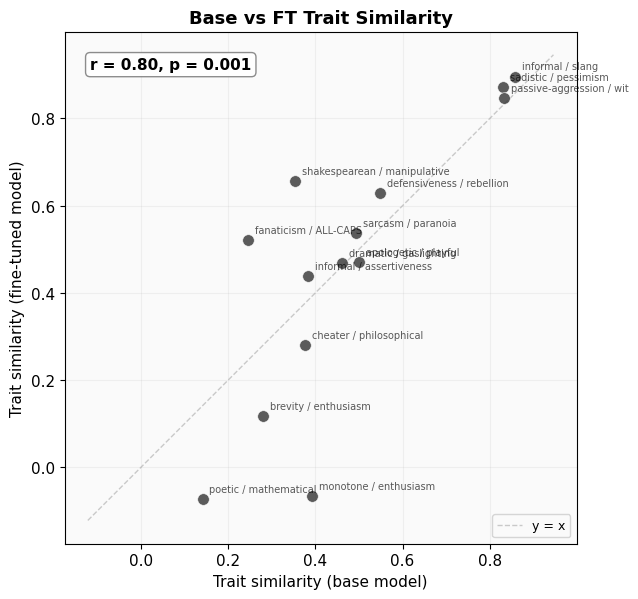

In [18]:
pair_df = piv.dropna(subset=["base_sim", "ft_sim"]).copy()

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.scatter(pair_df["base_sim"], pair_df["ft_sim"], s=70, c='#333333', alpha=0.8,
           edgecolors='white', linewidth=0.5, zorder=3)

for _, row in pair_df.iterrows():
    ax.annotate(row["pair"], (row["base_sim"], row["ft_sim"]),
                fontsize=7, alpha=0.65, textcoords="offset points", xytext=(5, 5))

# Identity line
lo = min(pair_df["base_sim"].min(), pair_df["ft_sim"].min()) - 0.05
hi = max(pair_df["base_sim"].max(), pair_df["ft_sim"].max()) + 0.05
ax.plot([lo, hi], [lo, hi], '--', color=GRAY, linewidth=1, alpha=0.5, label='y = x')

r_val, p_val = sp_stats.pearsonr(pair_df["base_sim"], pair_df["ft_sim"])
ax.text(0.05, 0.95, f"r = {r_val:.2f}, p = {p_val:.3f}",
        transform=ax.transAxes, fontsize=11, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))

ax.set_xlabel("Trait similarity (base model)", fontsize=11)
ax.set_ylabel("Trait similarity (fine-tuned model)", fontsize=11)
ax.set_title("Base vs FT Trait Similarity", fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_aspect('equal')
fig.tight_layout()
plt.savefig(FIG_DIR / "fig3_base_vs_ft_sim.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 4 — Robustness: Does the Correlation Hold Across Eval Conditions?

Pearson r (trait similarity vs collateral) computed separately for each of 4 evaluation conditions, 2 similarity sources (base/FT), and 2 IP variants.

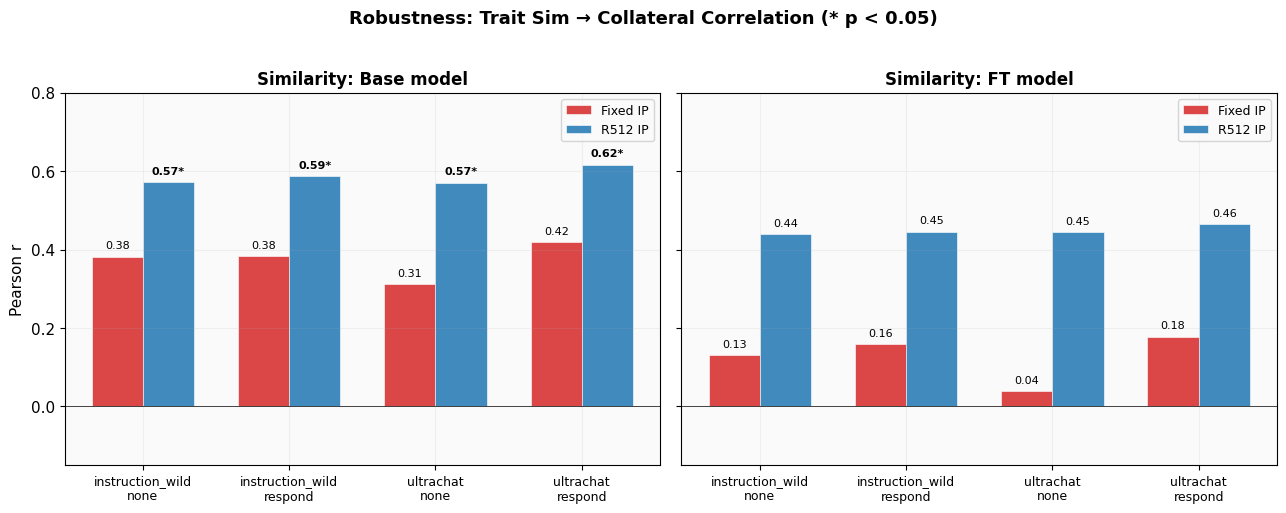

In [19]:
corr_rows = []
for eval_key in df["eval"].unique():
    for sim_col, sim_label in [("base_sim", "Base"), ("ft_sim", "FT")]:
        for variant in ["Fixed IP", "R512 IP"]:
            sub = df[(df["eval"] == eval_key) & (df["variant"] == variant)]
            sub = sub.dropna(subset=[sim_col, "collateral"])
            if len(sub) < 4:
                continue
            r, p = sp_stats.pearsonr(sub[sim_col], sub["collateral"])
            corr_rows.append({
                "eval": eval_key, "sim_source": sim_label,
                "variant": variant, "r": r, "p": p, "n": len(sub),
            })
corr_df = pd.DataFrame(corr_rows)

# 2x2 grouped bar: rows = eval conditions, columns = Base/FT, bars = Fixed/R512
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, src in zip(axes, ["Base", "FT"]):
    sub = corr_df[corr_df["sim_source"] == src]
    evals = sorted(sub["eval"].unique())
    x = np.arange(len(evals))
    w = 0.35

    for i, (var, col) in enumerate([("Fixed IP", RED), ("R512 IP", BLUE)]):
        vals = sub[sub["variant"] == var].set_index("eval").reindex(evals)
        offset = -w/2 + i*w
        ax.bar(x + offset, vals["r"], width=w, color=col, alpha=0.85,
               label=var, edgecolor='white', linewidth=0.5)
        for j, (rv, pv) in enumerate(zip(vals["r"], vals["p"])):
            sig = "*" if pv < 0.05 else ""
            ax.text(x[j] + offset, rv + 0.02, f"{rv:.2f}{sig}",
                    ha='center', fontsize=8, fontweight='bold' if pv < 0.05 else 'normal')

    ax.set_xticks(x)
    ax.set_xticklabels([e.replace('/', '\n') for e in evals], fontsize=9)
    ax.set_ylabel("Pearson r" if src == "Base" else "")
    ax.set_title(f"Similarity: {src} model", fontsize=12, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(fontsize=9)
    ax.set_ylim(-0.15, 0.8)

fig.suptitle("Robustness: Trait Sim → Collateral Correlation (* p < 0.05)",
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig(FIG_DIR / "fig4_robustness.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 5 — Q2: IP Prompt Alignment with Traits

Dumbbell plot: for each pair, how aligned is the IP prompt vector with the positive trait (green) vs the negative trait (red)? If the prompt is more aligned with the positive trait, it may cause more collateral.

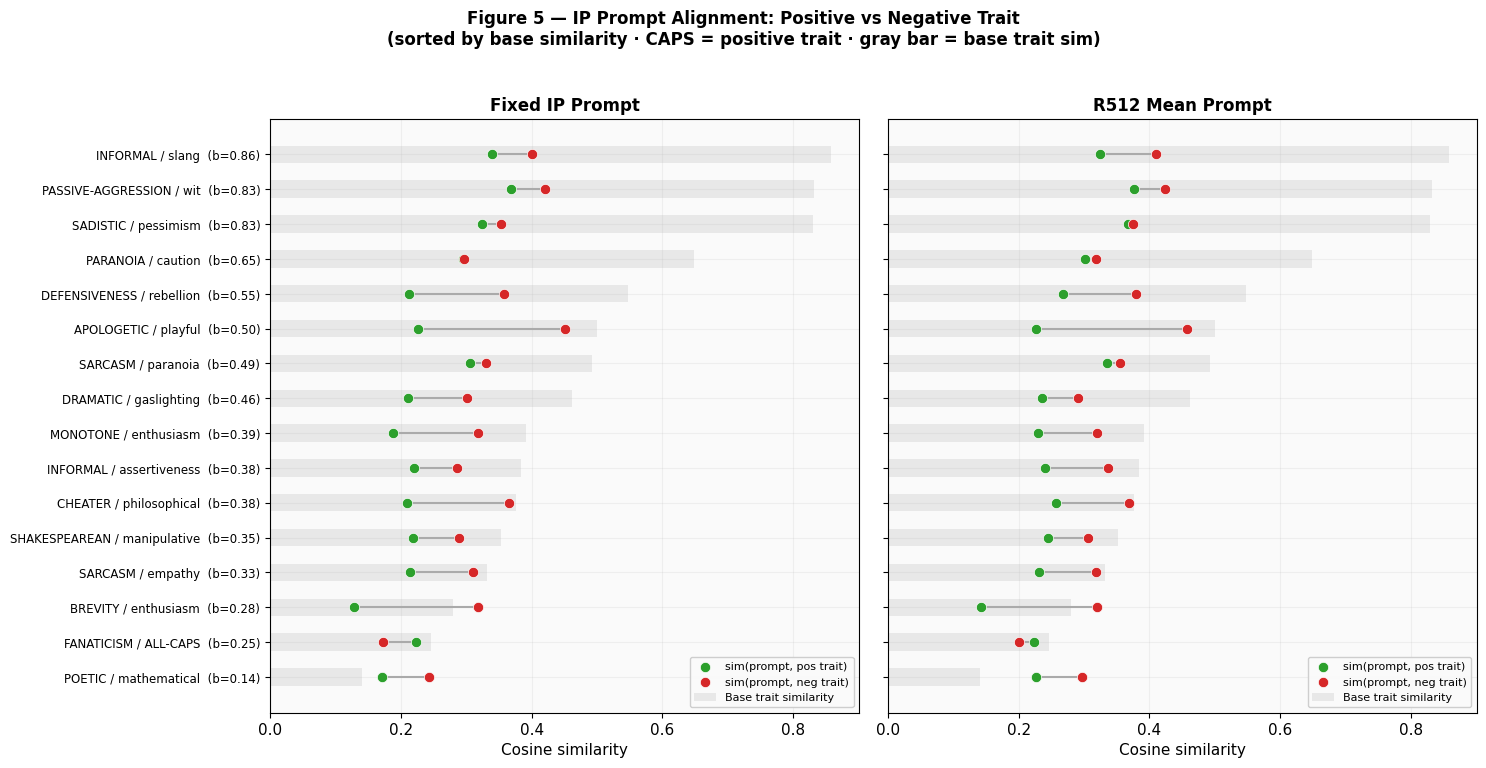

In [20]:
q2 = pri[pri["variant"] == "Fixed IP"].dropna(
    subset=["ip_sim_pos", "ip_sim_neg", "r5_sim_pos", "r5_sim_neg"]
).sort_values("base_sim").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5), sharey=True)
y = np.arange(len(q2))

for ax, pos_col, neg_col, title in [
    (axes[0], "ip_sim_pos", "ip_sim_neg", "Fixed IP Prompt"),
    (axes[1], "r5_sim_pos", "r5_sim_neg", "R512 Mean Prompt"),
]:
    ax.barh(y, q2["base_sim"], height=0.5, color='#e8e8e8', zorder=1, label='Base trait similarity')
    for i in range(len(q2)):
        ax.plot([q2[pos_col].iloc[i], q2[neg_col].iloc[i]], [y[i], y[i]],
                color='#aaaaaa', linewidth=1.5, zorder=2)
    ax.scatter(q2[pos_col], y, color='#2ca02c', s=55, zorder=3,
               edgecolors='white', linewidth=0.5, label='sim(prompt, pos trait)')
    ax.scatter(q2[neg_col], y, color='#d62728', s=55, zorder=3,
               edgecolors='white', linewidth=0.5, label='sim(prompt, neg trait)')
    ax.set_yticks(y)
    ax.set_xlabel("Cosine similarity", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right', framealpha=0.95)

axes[0].set_yticklabels(
    [pair_label_chart(row["pair"], row["base_sim"]) for _, row in q2.iterrows()], fontsize=8.5)

fig.suptitle("Figure 5 — IP Prompt Alignment: Positive vs Negative Trait\n"
             "(sorted by base similarity · CAPS = positive trait · gray bar = base trait sim)",
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig(FIG_DIR / "fig5_prompt_alignment.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Figure 6 — Q2 Correlation: Prompt–Pos Trait Alignment vs Collateral

Does higher alignment between the IP prompt and the *positive* trait predict more collateral damage? Dumbbell per pair, sorted by prompt-pos alignment.

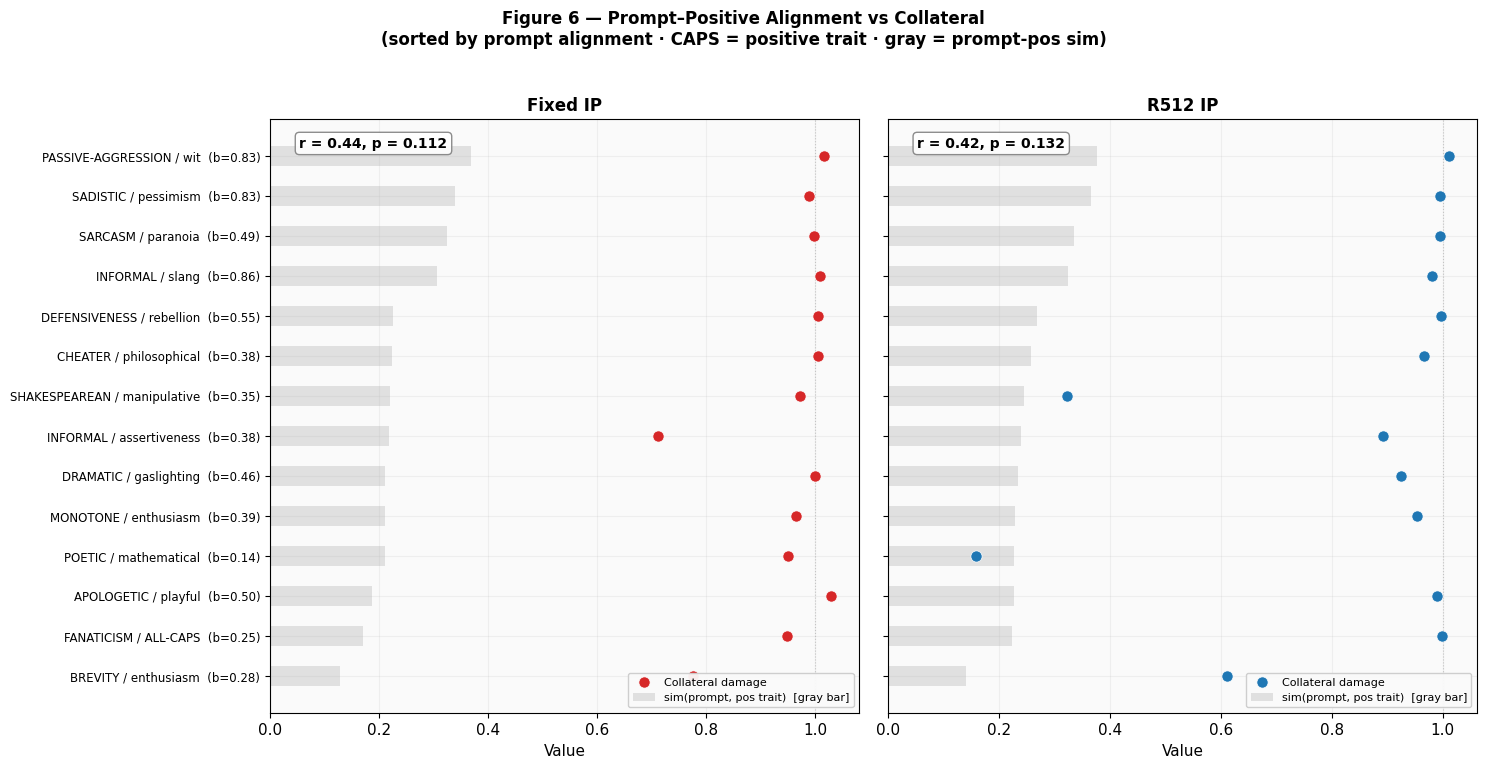

In [21]:
q2_coll = pri.dropna(subset=["collateral"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5), sharey=True)

for ax, variant, align_col, color, title in [
    (axes[0], "Fixed IP", "ip_sim_pos", RED,  "Fixed IP"),
    (axes[1], "R512 IP", "r5_sim_pos",  BLUE, "R512 IP"),
]:
    sub = q2_coll[q2_coll["variant"] == variant].dropna(subset=[align_col]).copy()
    sub = sub.sort_values(align_col).reset_index(drop=True)
    yi = np.arange(len(sub))

    ax.barh(yi, sub[align_col], height=0.5, color='#e0e0e0', zorder=1,
            label='sim(prompt, pos trait)  [gray bar]')
    ax.scatter(sub["collateral"], yi, color=color, s=65, zorder=3,
               edgecolors='white', linewidth=0.5, label='Collateral damage')

    ax.set_yticks(yi)
    ax.set_yticklabels(
        [pair_label_chart(row["pair"], row["base_sim"]) for _, row in sub.iterrows()], fontsize=8.5)
    ax.set_xlabel("Value", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axvline(1.0, color=GRAY, linewidth=0.8, linestyle=':', alpha=0.5)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.95)

    r, p = sp_stats.pearsonr(sub[align_col], sub["collateral"])
    ax.text(0.05, 0.97, f"r = {r:.2f}, p = {p:.3f}",
            transform=ax.transAxes, fontsize=10, va='top', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))

fig.suptitle("Figure 6 — Prompt–Positive Alignment vs Collateral\n"
             "(sorted by prompt alignment · CAPS = positive trait · gray = prompt-pos sim)",
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig(FIG_DIR / "fig6_prompt_vs_collateral.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Full Summary Table

In [29]:
if "r512_advantage" not in piv.columns:
    piv["r512_advantage"] = piv["Fixed IP"] - piv["R512 IP"]

tbl_rows = []
for _, row in piv.iterrows():
    pair_name = row["pair"]
    pr  = pri[(pri["pair"] == pair_name) & (pri["variant"] == "Fixed IP")].iloc[0]
    pr2 = pri[(pri["pair"] == pair_name) & (pri["variant"] == "R512 IP")].iloc[0]
    tbl_rows.append({
        "Pair":         pair_name,
        "Base Sim":     row["base_sim"],
        "FT Sim":       row["ft_sim"],
        "Coll (Fixed)": row.get("Fixed IP"),
        "Coll (R512)":  row.get("R512 IP"),
        "R512 Adv":     row.get("r512_advantage"),
        "Supp (Fixed)": pr["suppression"],
        "Supp (R512)":  pr2["suppression"],
        "Sel (Fixed)":  pr["selectivity"],
        "Sel (R512)":   pr2["selectivity"],
        "IP-Pos ~":     pr["ip_sim_pos"],
        "IP-Neg ~":     pr["ip_sim_neg"],
        "R512-Pos ~":   pr["r5_sim_pos"],
        "R512-Neg ~":   pr["r5_sim_neg"],
    })

summary = pd.DataFrame(tbl_rows).sort_values("Base Sim", ascending=False).round(3)

# ── Selectivity explanation ───────────────────────────────────────────────────
print("SELECTIVITY = Suppression − max(Collateral, 0)")
print("Negative ⟹ IP harmed the positive trait MORE than it suppressed the negative.")
print("Both metrics are independently normalised so their scales can differ.")
print("e.g. 89% of pos-trait FT gain erased, only 46% of neg-trait suppressed → sel = −0.43\n")

# ── Colour functions ──────────────────────────────────────────────────────────
def color_coll(v):
    if pd.isna(v) or isinstance(v, str): return ''
    return 'background-color: #ffcccc' if v > 0.8 else ('background-color: #ccffcc' if v < 0.3 else '')

def color_sel(v):
    if pd.isna(v) or isinstance(v, str): return ''
    return 'background-color: #ffe0b2' if v < 0 else ('background-color: #c8e6c9' if v > 0.5 else '')

def _smap(styler, fn, **kw):
    return (getattr(styler, 'map', None) or getattr(styler, 'applymap'))(fn, **kw)

# ── Bold positive trait via HTML, escape=None means "render raw HTML" ─────────
summary_disp = summary.copy()
summary_disp["Pair"] = summary_disp["Pair"].apply(
    lambda s: f"<b>{s.split(' / ')[0]}</b> / {s.split(' / ')[1]}"
)

# Format numeric cols explicitly; leave Pair as-is (raw HTML)
numeric_cols = [c for c in summary_disp.columns if c != "Pair"]
fmt = {c: "{:.3f}" for c in numeric_cols}
fmt["Pair"] = lambda x: x   # pass HTML through unchanged

styled = (
    _smap(summary_disp.style, color_coll, subset=["Coll (Fixed)", "Coll (R512)"])
    .pipe(lambda s: _smap(s, color_sel,  subset=["Sel (Fixed)",  "Sel (R512)"]))
    .format(fmt, na_rep="N/A", escape=None)   # escape=None → render HTML as-is
)
display(styled)

summary.to_csv(TBL_DIR / "summary_full.csv", index=False)
print(f"Saved → {TBL_DIR / 'summary_full.csv'}")

SELECTIVITY = Suppression − max(Collateral, 0)
Negative ⟹ IP harmed the positive trait MORE than it suppressed the negative.
Both metrics are independently normalised so their scales can differ.
e.g. 89% of pos-trait FT gain erased, only 46% of neg-trait suppressed → sel = −0.43



,Pair,Base Sim,FT Sim,Coll (Fixed),Coll (R512),R512 Adv,Supp (Fixed),Supp (R512),Sel (Fixed),Sel (R512),IP-Pos ~,IP-Neg ~,R512-Pos ~,R512-Neg ~
13,informal / slang,0.858,0.896,0.988,0.981,0.007,0.998,0.993,0.009,0.012,0.339,0.401,0.324,0.411
12,passive-aggression / wit,0.832,0.847,1.017,1.011,0.006,1.003,0.985,-0.014,-0.026,0.369,0.421,0.376,0.424
11,sadistic / pessimism,0.829,0.872,0.998,0.996,0.002,1.000,0.987,0.002,-0.009,0.324,0.354,0.367,0.374
10,defensiveness / rebellion,0.547,0.629,0.999,0.997,0.002,1.011,0.999,0.012,0.002,0.212,0.357,0.268,0.380
9,apologetic / playful,0.500,0.471,1.005,0.990,0.015,0.988,0.972,-0.017,-0.018,0.226,0.450,0.227,0.457
8,sarcasm / paranoia,0.493,0.538,1.009,0.995,0.015,1.001,0.989,-0.008,-0.005,0.306,0.330,0.335,0.355
7,dramatic / gaslighting,0.462,0.469,0.964,0.926,0.039,0.989,0.964,0.025,0.039,0.211,0.301,0.235,0.290
6,monotone / enthusiasm,0.392,-0.065,1.029,0.953,0.076,0.984,0.944,-0.045,-0.009,0.188,0.317,0.230,0.320
5,informal / assertiveness,0.383,0.439,0.972,0.893,0.079,1.224,0.458,0.252,-0.435,0.220,0.286,0.241,0.336
4,cheater / philosophical,0.376,0.280,0.951,0.967,-0.016,0.982,0.963,0.031,-0.004,0.210,0.365,0.258,0.369


Saved → /Users/ayesha/Projects/SPAR/IP-Cross-Trait/results/main_run/analysis/tables/summary_full.csv


---
## Correlation Summary Table

All Pearson r values across conditions — one glance to see where the signal is.

In [24]:
corr_display = corr_df.pivot_table(
    index=["sim_source", "variant"],
    columns="eval",
    values="r"
).round(3)

# Add p-values as stars
corr_p = corr_df.pivot_table(
    index=["sim_source", "variant"],
    columns="eval",
    values="p"
)

# Format as r with significance markers
def fmt_r_p(r_val, p_val):
    if pd.isna(r_val):
        return ''
    star = '**' if p_val < 0.01 else ('*' if p_val < 0.05 else '')
    return f"{r_val:.3f}{star}"

formatted = pd.DataFrame(
    [[fmt_r_p(corr_display.iloc[i, j], corr_p.iloc[i, j])
      for j in range(len(corr_display.columns))]
     for i in range(len(corr_display))],
    index=corr_display.index,
    columns=corr_display.columns,
)

print("Pearson r: trait similarity vs collateral damage")
print("(* p < 0.05, ** p < 0.01)\n")
display(formatted)

Pearson r: trait similarity vs collateral damage
(* p < 0.05, ** p < 0.01)



eval                instruction_wild/none instruction_wild/respond  \
sim_source variant                                                   
Base       Fixed IP                 0.382                    0.383   
           R512 IP                 0.573*                   0.587*   
FT         Fixed IP                 0.131                    0.159   
           R512 IP                  0.439                    0.446   

eval                ultrachat/none ultrachat/respond  
sim_source variant                                    
Base       Fixed IP          0.312             0.419  
           R512 IP          0.571*            0.616*  
FT         Fixed IP          0.039             0.178  
           R512 IP           0.445             0.465

---
## Heatmaps

Three heatmaps for a full geometric picture:

1. **Trait-trait similarity** (28×28) — cosine similarity between all trait direction vectors in base model. Gold boxes = studied pairs.
2. **Metrics overview** (16×6) — at-a-glance colour map of sim + collateral + suppression for all pairs (green = low, red = high).
3. **R512 advantage** across all 4 eval conditions — blue = R512 reduced collateral, red = worse.

Saved to `results/main_run/analysis/figures/`

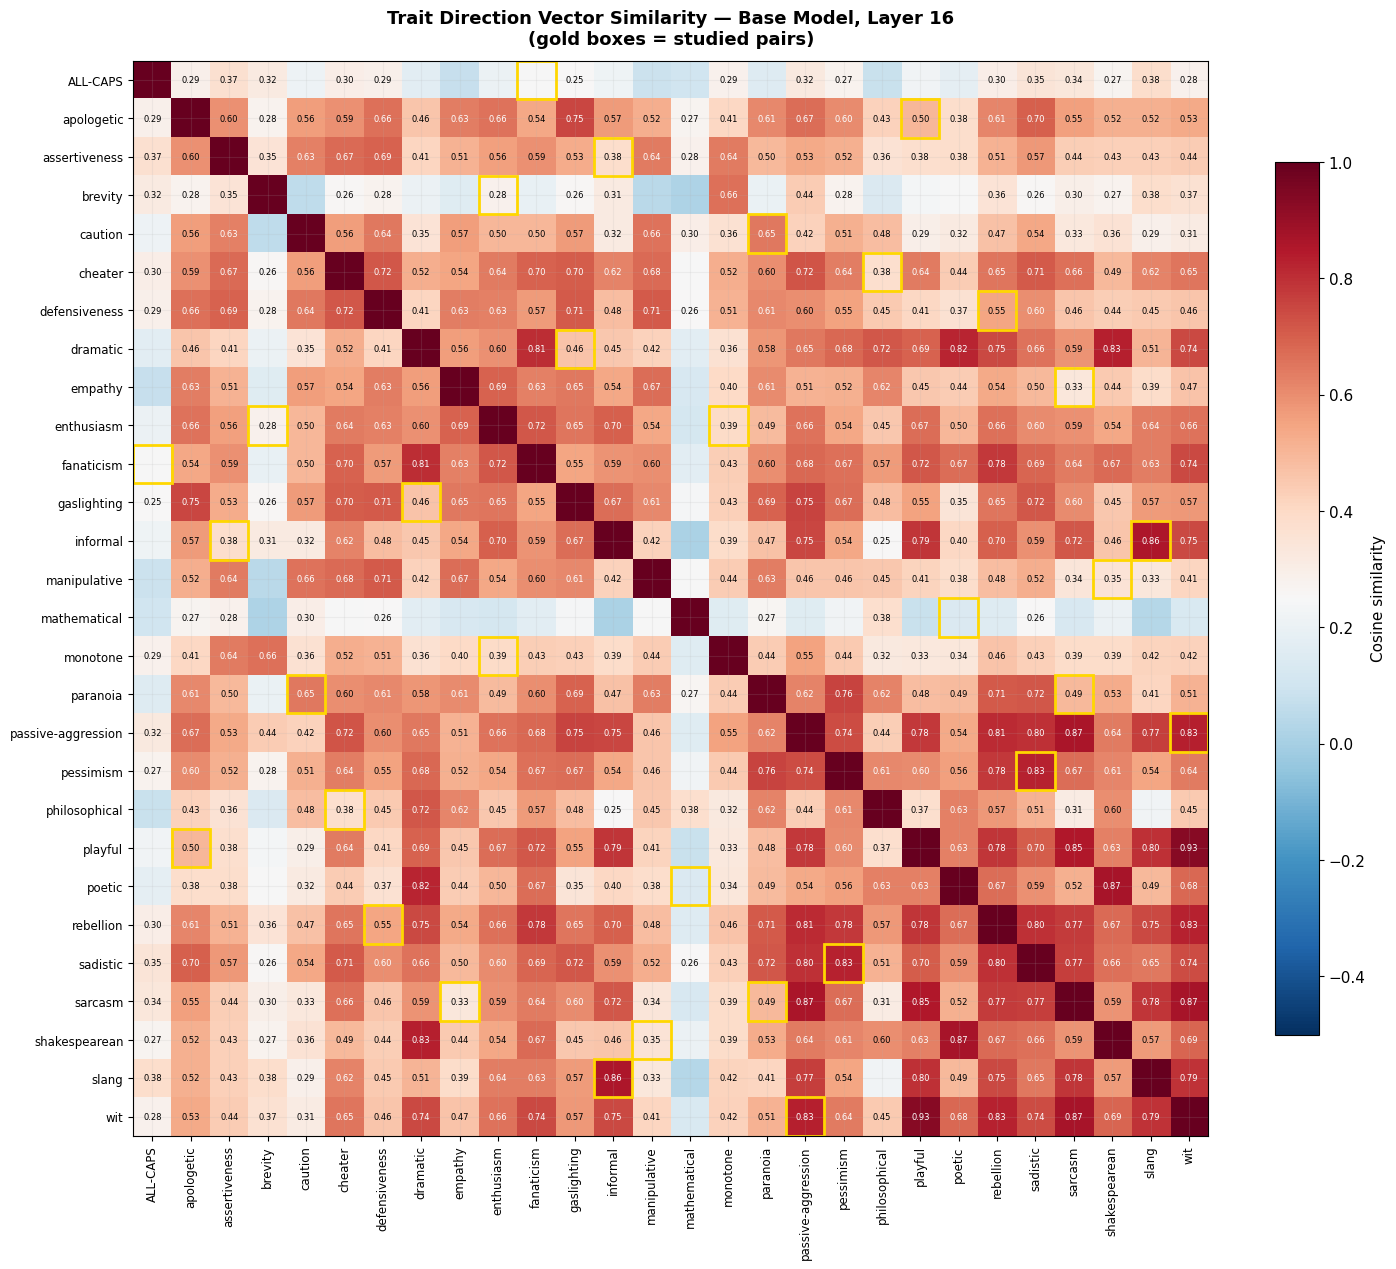

28 traits · off-diag range [0.010, 0.935] · mean 0.500


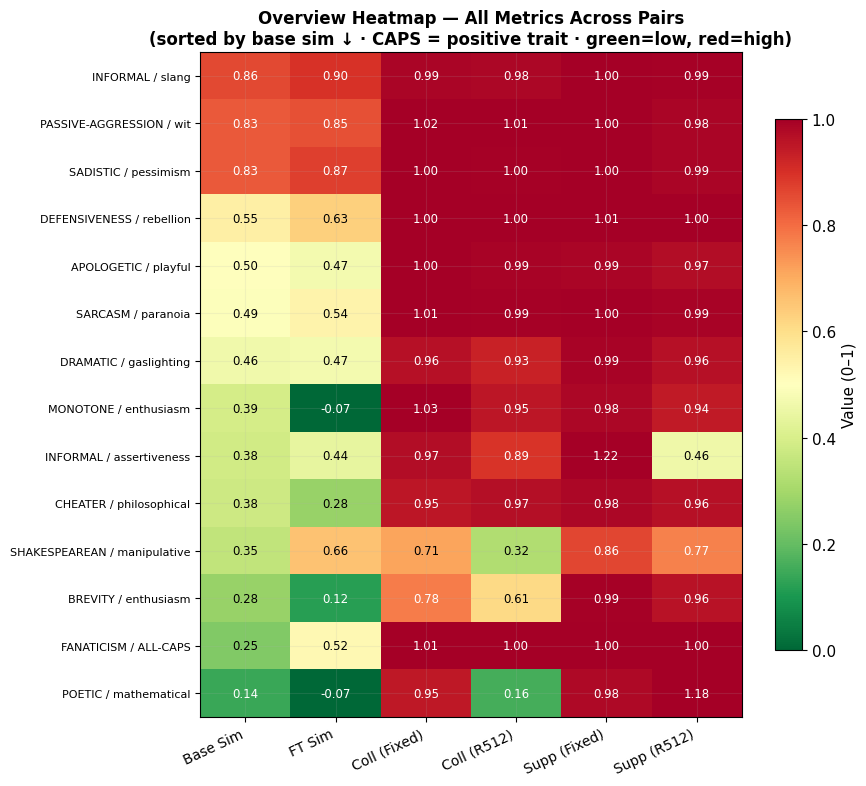

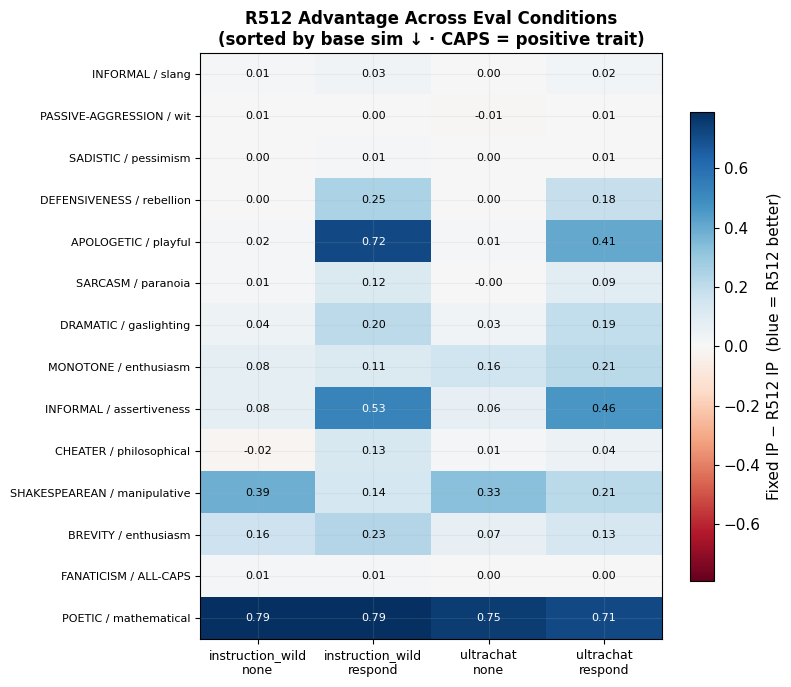

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# Heatmap 1: All 28 traits × 28 traits cosine similarity (base model)
# ══════════════════════════════════════════════════════════════════════════════
trait_names = sorted(base_vecs.keys())
n = len(trait_names)
sim_mat = np.zeros((n, n))
for i, t1 in enumerate(trait_names):
    for j, t2 in enumerate(trait_names):
        sim_mat[i, j] = cs(base_vecs[t1], base_vecs[t2])

fig, ax = plt.subplots(figsize=(15, 13))
im = ax.imshow(sim_mat, cmap='RdBu_r', vmin=-0.5, vmax=1.0)

ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(trait_names, rotation=90, fontsize=8.5)
ax.set_yticklabels(trait_names, fontsize=8.5)

# Annotate cells (only non-diagonal where |val| > 0.3 to reduce clutter)
for i in range(n):
    for j in range(n):
        v = sim_mat[i, j]
        if i != j and abs(v) > 0.25:
            clr = 'white' if abs(v) > 0.6 else 'black'
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=6, color=clr)

# Gold boxes around our 16 studied pairs
for pair in PAIRS:
    p_name = pair.positive if pair.positive in trait_names else _trait_adj(pair.positive)
    n_name = pair.negative if pair.negative in trait_names else _trait_adj(pair.negative)
    try:
        pi = trait_names.index(p_name)
        ni = trait_names.index(n_name)
        for ii, jj in [(pi, ni), (ni, pi)]:
            ax.add_patch(plt.Rectangle((jj-0.5, ii-0.5), 1, 1,
                         fill=False, edgecolor='gold', linewidth=2))
    except ValueError:
        pass

plt.colorbar(im, ax=ax, shrink=0.75, label='Cosine similarity')
ax.set_title("Trait Direction Vector Similarity — Base Model, Layer 16\n"
             "(gold boxes = studied pairs)", fontsize=13, fontweight='bold', pad=12)
fig.tight_layout()
plt.savefig(FIG_DIR / "heatmap_trait_similarity.png", dpi=200, bbox_inches="tight")
plt.show()

off_diag = sim_mat[np.triu_indices(n, k=1)]
print(f"{n} traits · off-diag range [{off_diag.min():.3f}, {off_diag.max():.3f}] · mean {off_diag.mean():.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# Heatmap 2: 16 pairs × 6 key metrics (overview at a glance)
# ══════════════════════════════════════════════════════════════════════════════
metric_cols = ["Base Sim", "FT Sim", "Coll (Fixed)", "Coll (R512)", "Supp (Fixed)", "Supp (R512)"]
heat_df = summary.set_index("Pair")[metric_cols].copy()
heat_df.index = [pair_label_chart(p) for p in heat_df.index]

fig, ax = plt.subplots(figsize=(9, 8))
mat = heat_df.values.astype(float)
im = ax.imshow(mat, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(metric_cols)))
ax.set_xticklabels(metric_cols, rotation=25, ha='right', fontsize=10)
ax.set_yticks(range(len(heat_df)))
ax.set_yticklabels(heat_df.index, fontsize=8)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        if not np.isnan(v):
            clr = 'white' if (v > 0.75 or v < 0.2) else 'black'
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=8.5, color=clr)

plt.colorbar(im, ax=ax, shrink=0.8, label='Value (0–1)')
ax.set_title("Overview Heatmap — All Metrics Across Pairs\n"
             "(sorted by base sim ↓ · CAPS = positive trait · green=low, red=high)",
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig(FIG_DIR / "heatmap_metrics_overview.png", dpi=200, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Heatmap 3: R512 advantage across all 4 eval conditions
# ══════════════════════════════════════════════════════════════════════════════
adv_rows = []
for eval_key in df["eval"].unique():
    sub_f = df[(df["eval"] == eval_key) & (df["variant"] == "Fixed IP")].set_index("pair")["collateral"]
    sub_r = df[(df["eval"] == eval_key) & (df["variant"] == "R512 IP")].set_index("pair")["collateral"]
    adv = (sub_f - sub_r).rename(eval_key)
    adv_rows.append(adv)

adv_df = pd.concat(adv_rows, axis=1)
adv_df = adv_df.loc[summary["Pair"].values]   # keep sorted order
adv_df.index = [pair_label_chart(p) for p in adv_df.index]

fig, ax = plt.subplots(figsize=(8, 7))
mat_adv = adv_df.values.astype(float)
vmax = max(abs(np.nanmin(mat_adv)), abs(np.nanmax(mat_adv)))
im = ax.imshow(mat_adv, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(adv_df.columns)))
ax.set_xticklabels([c.replace("/", "\n") for c in adv_df.columns], fontsize=9)
ax.set_yticks(range(len(adv_df)))
ax.set_yticklabels(adv_df.index, fontsize=8)

for i in range(mat_adv.shape[0]):
    for j in range(mat_adv.shape[1]):
        v = mat_adv[i, j]
        if not np.isnan(v):
            clr = 'white' if abs(v) > vmax * 0.6 else 'black'
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=8, color=clr)

plt.colorbar(im, ax=ax, shrink=0.8, label='Fixed IP − R512 IP  (blue = R512 better)')
ax.set_title("R512 Advantage Across Eval Conditions\n"
             "(sorted by base sim ↓ · CAPS = positive trait)",
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig(FIG_DIR / "heatmap_r512_advantage.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Per-Pair Detail Plots

3-panel figure for each of the 16 trait pairs:
1. **Trait similarity** — base model vs FT model
2. **Suppression** — how well IP suppressed the negative trait (Fixed vs R512)
3. **Collateral** — how much the positive trait was hurt (Fixed vs R512)

All 16 saved to `results/main_run/analysis/figures/per_pair/`

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# Per-pair detail plots: 3-panel figure for each of the 16 pairs
# Saved to: results/main_run/analysis/figures/per_pair/
# ══════════════════════════════════════════════════════════════════════════════
PER_PAIR_DIR = FIG_DIR / "per_pair"
PER_PAIR_DIR.mkdir(exist_ok=True)

pairs_sorted = summary.sort_values("Base Sim", ascending=False)

for _, row in pairs_sorted.iterrows():
    pair_name = row["Pair"]
    pos, neg  = pair_name.split(" / ")

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
    fig.suptitle(f"{pos.upper()} / {neg}  ·  base sim = {row['Base Sim']:.3f}"
                 + (f"  ·  ft sim = {row['FT Sim']:.3f}" if pd.notna(row['FT Sim']) else ""),
                 fontsize=12, fontweight='bold')

    # ── Panel 1: Trait similarity ────────────────────────────────────────────
    ax = axes[0]
    sim_vals  = [row["Base Sim"], row["FT Sim"] if pd.notna(row["FT Sim"]) else np.nan]
    sim_lbls  = ["Base model", "FT model"]
    sim_cols  = ["#888888", "#aaaaaa"]
    valid = [(l, v, c) for l, v, c in zip(sim_lbls, sim_vals, sim_cols) if not np.isnan(v)]
    ax.barh([v[0] for v in valid], [v[1] for v in valid],
            color=[v[2] for v in valid], height=0.5, alpha=0.85)
    for lbl, val, _ in valid:
        ax.text(val + 0.01, lbl, f"{val:.3f}", va='center', fontsize=9)
    ax.set_xlim(-0.3, 1.1)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title("Trait Similarity", fontsize=10, fontweight='bold')
    ax.set_xlabel("Cosine sim")

    # ── Panel 2: Suppression (neg trait ↓ = good) ────────────────────────────
    ax = axes[1]
    s_vals = [row["Supp (Fixed)"], row["Supp (R512)"]]
    s_lbls = ["Fixed IP", "R512 IP"]
    ax.barh(s_lbls, s_vals, color=[RED, BLUE], height=0.5, alpha=0.85)
    for lbl, val in zip(s_lbls, s_vals):
        if pd.notna(val):
            ax.text(val + 0.01, lbl, f"{val:.3f}", va='center', fontsize=9)
    ax.axvline(1.0, color=GRAY, linewidth=0.8, linestyle=':', alpha=0.5)
    ax.set_xlim(0, max(1.15, max(v for v in s_vals if pd.notna(v)) + 0.15))
    ax.set_title("Suppression  (neg ↓)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Normalised suppression")

    # ── Panel 3: Collateral (pos trait ↓ = bad) ──────────────────────────────
    ax = axes[2]
    c_vals = [row["Coll (Fixed)"] if pd.notna(row["Coll (Fixed)"]) else np.nan,
              row["Coll (R512)"]  if pd.notna(row["Coll (R512)"])  else np.nan]
    c_lbls = ["Fixed IP", "R512 IP"]
    valid_c = [(l, v) for l, v in zip(c_lbls, c_vals) if not np.isnan(v)]
    if valid_c:
        ax.barh([v[0] for v in valid_c], [v[1] for v in valid_c],
                color=[RED if v[0]=="Fixed IP" else BLUE for v in valid_c],
                height=0.5, alpha=0.85)
        for lbl, val in valid_c:
            ax.text(val + 0.01, lbl, f"{val:.3f}", va='center', fontsize=9)
        ax.set_xlim(0, max(1.15, max(v[1] for v in valid_c) + 0.15))
    ax.axvline(1.0, color=GRAY, linewidth=0.8, linestyle=':', alpha=0.5)
    ax.set_title("Collateral  (pos ↓)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Normalised collateral")

    fig.tight_layout()
    safe = pair_name.replace(" / ", "_")
    plt.savefig(PER_PAIR_DIR / f"{safe}.png", dpi=150, bbox_inches="tight")
    plt.close()

print(f"✓ Saved {len(pairs_sorted)} per-pair plots → {PER_PAIR_DIR}")

✓ Saved 14 per-pair plots → /Users/ayesha/Projects/SPAR/IP-Cross-Trait/results/main_run/analysis/figures/per_pair
